In [11]:
from src.config import *
from src.data import *
from src.models import *
from src.plot import *

In [12]:
cfg = load_config('config.yaml')
df, tmp_sensors, sensors = load_data(cfg)
df = df.sort_values(by='time').reset_index(drop=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data is loaded and preprocessed. All sensors are downsampled to thermometers' frequency (direct subsampling, no aggregation or smoothing). NaNs are replaced with mean value.

In [13]:
# Preview as HTML table with numeric formatting
from IPython.display import display

num_cols = df.select_dtypes(include=["number"]).columns
preview = (
    df.head(15)
    .style.format({c: "{:.4f}" for c in num_cols}, na_rep="—")
    .set_caption(f"DataFrame preview ({len(df)} rows and {len(df.columns)} cols)")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "1.1em"), ("font-weight", "bold")]}])
)
display(preview)

,time,03068004_x,03068004_y,030681F6_x,030681F6_y,030681F7_x,030681F7_y,0306825C_x,0306825C_y,09876543_e,2302679F_s,2301290F_t
0,2025-10-01 00:00:00,-0.2042,0.1876,0.2504,1.5149,0.7210,1.4242,0.1473,4.4889,20.7389,79.5869,16.3609
1,2025-10-01 00:15:00,-0.2057,0.1871,0.2504,1.5134,0.7208,1.4250,0.1474,4.4897,20.7449,79.5923,16.7698
2,2025-10-01 00:30:00,-0.2051,0.1879,0.2501,1.5148,0.7194,1.4250,0.1470,4.4878,20.7610,79.6035,16.8127
3,2025-10-01 00:45:00,-0.2053,0.1873,0.2491,1.5146,0.7212,1.4253,0.1465,4.4875,20.7465,79.5914,16.7233
4,2025-10-01 01:00:00,-0.2041,0.1876,0.2499,1.5145,0.7206,1.4245,0.1470,4.4871,20.7407,79.5984,16.6193
5,2025-10-01 01:15:00,-0.2046,0.1879,0.2505,1.5156,0.7201,1.4244,0.1472,4.4876,20.7445,79.5889,16.2131
6,2025-10-01 01:30:00,-0.2046,0.1880,0.2504,1.5142,0.7204,1.4248,0.1467,4.4880,20.7351,79.5832,15.9341
7,2025-10-01 01:45:00,-0.2051,0.1878,0.2495,1.5152,0.7204,1.4235,0.1481,4.4881,20.7154,79.5844,15.6025
8,2025-10-01 02:00:00,-0.2049,0.1881,0.2512,1.5154,0.7201,1.4244,0.1466,4.4888,20.6800,79.5876,14.9481
9,2025-10-01 02:15:00,-0.2053,0.1875,0.2500,1.5154,0.7204,1.4241,0.1471,4.4873,20.6304,79.5889,14.3008


In [14]:
sensor = sensors[2]
df_s = df[df[sensor].notna()]
# 3. Esegui modelli
print("\n[models] Esecuzione modelli...")
results = run_models(df_s, tmp_sensors, [sensor], cfg, filename=sensor)


[models] Esecuzione modelli...
[MLR (lag 96, 15min)]  RMSE=0.0012  R²=0.7858  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 48, 30min)]  RMSE=0.0011  R²=0.8281  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 24, 1h)]  RMSE=0.0010  R²=0.8529  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 12, 2h)]  RMSE=0.0009  R²=0.8683  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 6, 4h)]  RMSE=0.0008  R²=0.8889  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 3, 8h)]  RMSE=0.0007  R²=0.8996  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 2, 12h)]  RMSE=0.0008  R²=0.8825  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 1, 1d)]  RMSE=0.0007  R²=0.8916  |  feature=2301290F_t  target=030681F6_x
[MLR (lag 0, 2d)]  RMSE=0.0007  R²=0.8995  |  feature=2301290F_t  target=030681F6_x


# Performance comparison

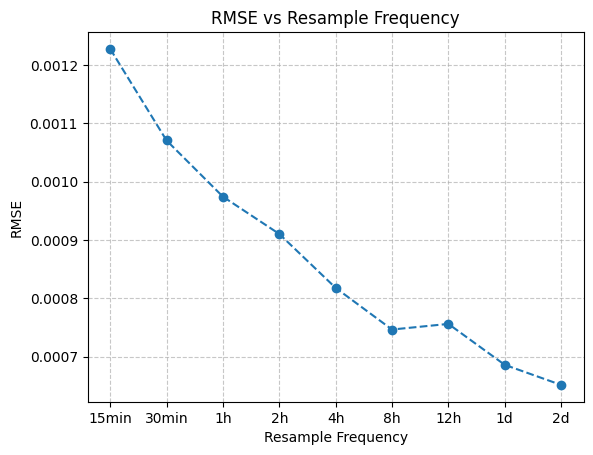

In [15]:
plt.plot([r.resample_freq for r in results], [r.rmse for r in results], 'o--')
plt.xlabel('Resample Frequency')
plt.ylabel('RMSE')
plt.title('RMSE vs Resample Frequency')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

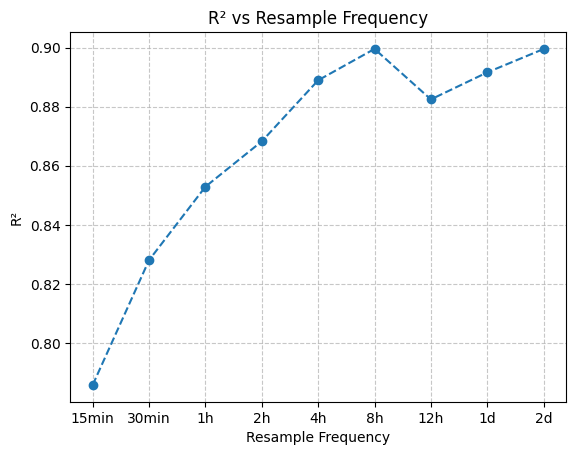

In [16]:
plt.plot([r.resample_freq for r in results], [r.r2 for r in results], 'o--')
plt.xlabel('Resample Frequency')
plt.ylabel('R²')
plt.title('R² vs Resample Frequency')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

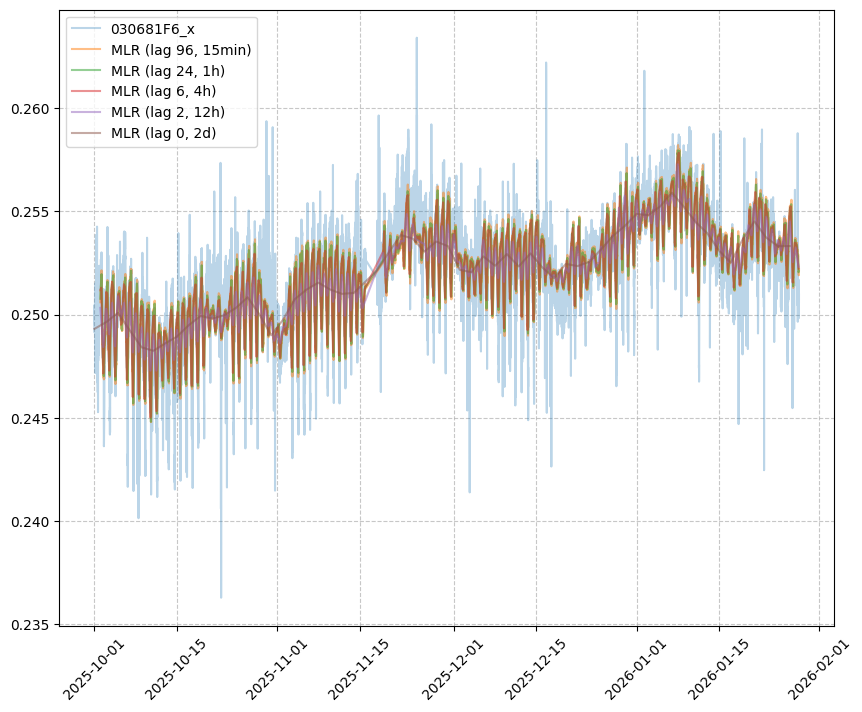

In [17]:
plt.figure(figsize=(10, 8))
plt.plot(df_s['time'], df_s[sensor], label=sensor, alpha=0.3)
for idx in range(0, len(results), 2):
    plt.plot(results[idx].t, results[idx].y_pred, label=results[idx].name, alpha=0.5)
plt.grid(linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [18]:
for r in results:
    print(r.t[0], r.t[-1])

2025-10-02 00:00:00 2026-01-28 13:45:00
2025-10-02 00:00:00 2026-01-28 13:30:00
2025-10-02 00:00:00 2026-01-28 13:00:00
2025-10-02 00:00:00 2026-01-28 12:00:00
2025-10-02 00:00:00 2026-01-28 12:00:00
2025-10-02 00:00:00 2026-01-28 08:00:00
2025-10-02 00:00:00 2026-01-28 12:00:00
2025-10-02 00:00:00 2026-01-28 00:00:00
2025-10-01 00:00:00 2026-01-27 00:00:00
